# 53 - 顔類似検索: 同一人物の発見

`terada` カテゴリ (10枚のポートレート) の顔をクエリとして、
カンファレンス写真群から同一人物を検索する。

## 入力
- `data/images.duckdb` (face_detections テーブル, image_catalog テーブル)

## 目的
- 顔 Embedding による同一人物検索の有効性を確認
- 類似度スコアの分布分析と閾値の検討
- 1画像に複数顔がある場合の個別マッチングの確認

In [1]:
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
EMBEDDING_DIM = 512
MODEL_NAME = "insightface/buffalo_l"
TOP_K = 20  # 検索結果数

## データ読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 顔検出データの概要
total_faces = conn.execute("SELECT COUNT(*) FROM face_detections").fetchone()[0]
total_images_with_faces = conn.execute("SELECT COUNT(DISTINCT image_id) FROM face_detections").fetchone()[0]

print(f"総検出顔数: {total_faces}")
print(f"顔がある画像数: {total_images_with_faces}")

# terada の顔データ
terada_faces = conn.execute("""
    SELECT 
        f.face_id, f.image_id, f.embedding, f.det_score, f.age, f.gender,
        f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
        c.file_name, c.file_path, c.category
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category = 'terada'
    ORDER BY c.file_name, f.det_score DESC
""").fetchdf()

print(f"\nterada カテゴリの顔数: {len(terada_faces)}")
display(terada_faces[["file_name", "det_score", "age", "gender"]])

総検出顔数: 691
顔がある画像数: 182

terada カテゴリの顔数: 10


,file_name,det_score,age,gender
0,202203証明写真オリジナル.jpg,0.900003,49,M
1,TeradaPyConJP.jpg,0.873109,49,M
2,terada-2020-square-500.jpg,0.887685,41,M
3,terada-202205-pyconjp-4-3-900.jpg,0.912513,57,M
4,terada-pao-2025.jpg,0.896674,60,M
5,terada-pyconjp2019.jpg,0.798663,72,M
6,terada-uspycon2019-up.jpg,0.885319,54,M
7,terada.jpg,0.808236,56,M
8,terada2.jpg,0.862755,55,M
9,terada_pythonbr_thumb.png,0.870584,49,M


## terada クエリ顔の確認

各ポートレートのクエリ顔を表示する。

In [4]:
def crop_face(file_path: str, bbox_x1: float, bbox_y1: float, bbox_x2: float, bbox_y2: float, padding: int = 20) -> Image.Image:
    """画像から顔をクロップする"""
    img = Image.open(file_path).convert("RGB")
    x1 = max(0, int(bbox_x1) - padding)
    y1 = max(0, int(bbox_y1) - padding)
    x2 = min(img.width, int(bbox_x2) + padding)
    y2 = min(img.height, int(bbox_y2) + padding)
    return img.crop((x1, y1, x2, y2))

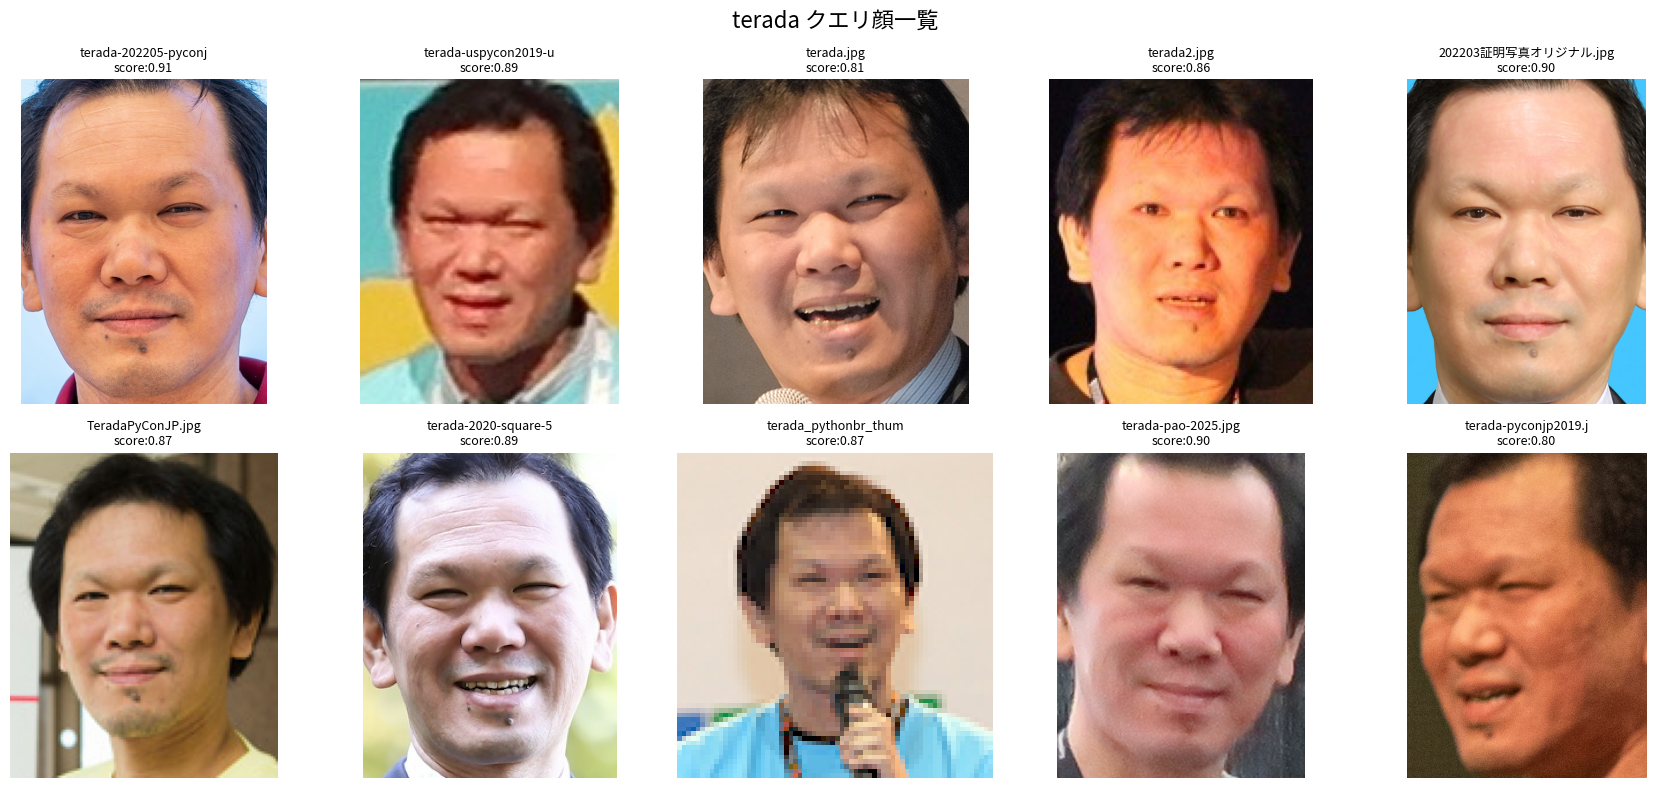

In [5]:
# terada の各画像で最高スコアの顔を1つ選択
terada_query_faces = terada_faces.groupby("image_id").first().reset_index()

n = len(terada_query_faces)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 4 * rows))
axes = np.array(axes).flatten()

for idx, (_, row) in enumerate(terada_query_faces.iterrows()):
    face_crop = crop_face(row["file_path"], row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
    axes[idx].imshow(face_crop)
    axes[idx].set_title(f"{row['file_name'][:20]}\nscore:{row['det_score']:.2f}", fontsize=9)
    axes[idx].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.suptitle("terada クエリ顔一覧", fontsize=16)
plt.tight_layout()
plt.show()

## 各クエリ顔で類似検索

各 terada ポートレートの顔 Embedding をクエリとして、全顔に対してコサイン類似度検索を実行する。

In [6]:
all_search_results = []

for _, query_row in terada_query_faces.iterrows():
    query_embedding = [float(x) for x in query_row["embedding"]]

    results = conn.execute(f"""
        SELECT 
            f.face_id,
            f.image_id,
            c.file_name,
            c.file_path,
            c.category,
            f.det_score,
            f.age,
            f.gender,
            f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
            array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        ORDER BY distance
        LIMIT {TOP_K}
    """, [query_embedding]).fetchdf()

    results["similarity"] = 1.0 - results["distance"]
    results["query_file"] = query_row["file_name"]
    results["query_face_id"] = query_row["face_id"]
    all_search_results.append(results)

df_results = pd.concat(all_search_results, ignore_index=True)
print(f"検索結果数: {len(df_results)}")
print(f"クエリ数: {len(terada_query_faces)}")

検索結果数: 200
クエリ数: 10


## 検索結果の可視化: クエリ顔 + Top-10 マッチ

各クエリに対して、最も類似した顔を顔クロップのグリッドで表示する。

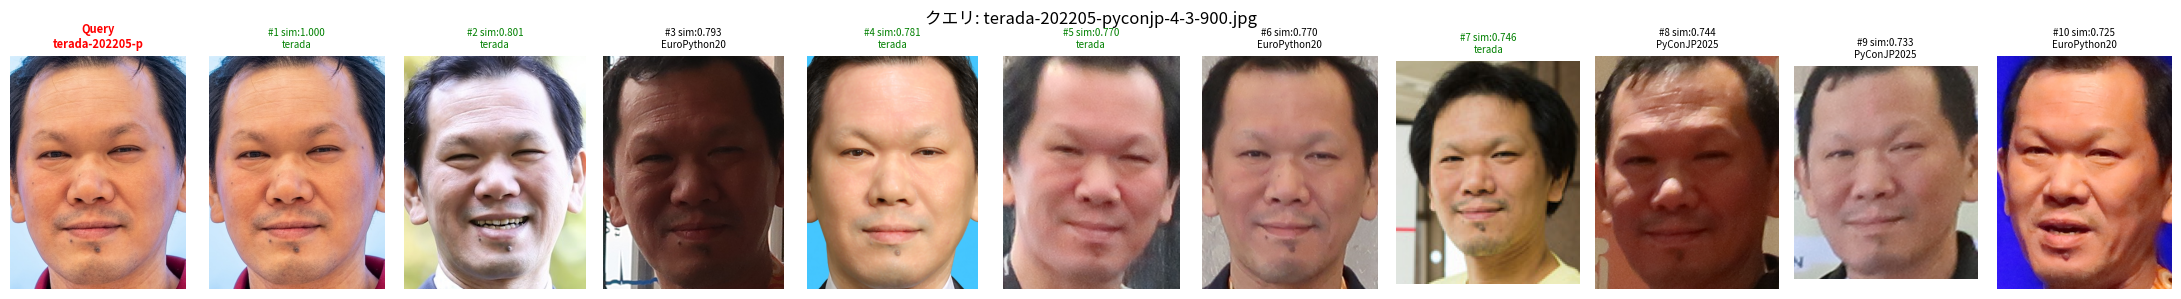

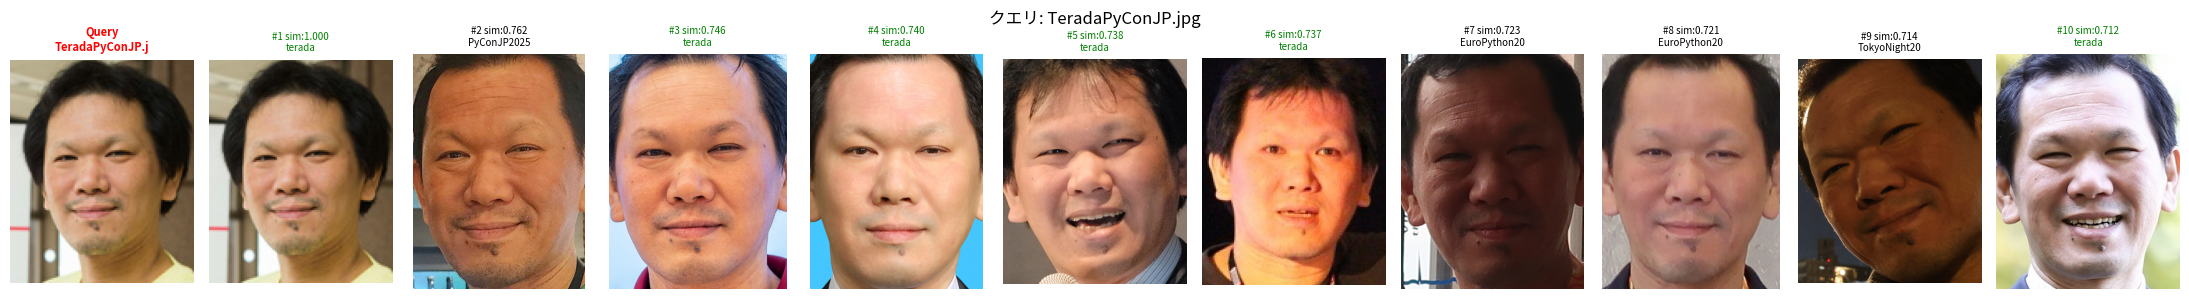

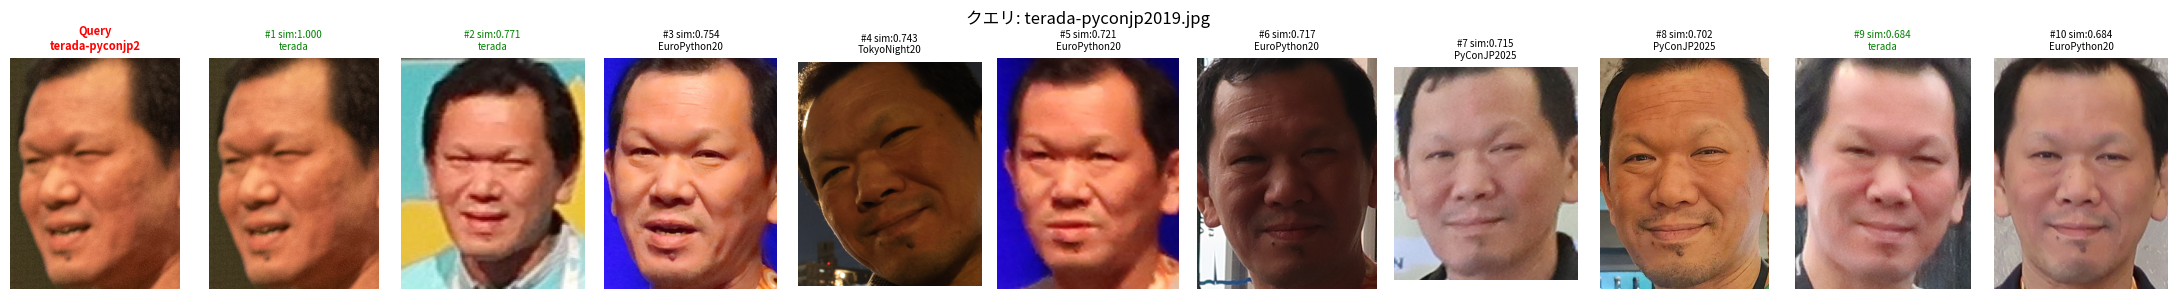

In [7]:
# 代表的なクエリ3つの結果を詳細表示
query_indices = [0, len(terada_query_faces) // 2, len(terada_query_faces) - 1]
query_indices = [i for i in query_indices if i < len(terada_query_faces)]

for q_idx in query_indices:
    query_row = terada_query_faces.iloc[q_idx]
    query_results = df_results[df_results["query_face_id"] == query_row["face_id"]].head(11)  # +1 for self

    fig, axes = plt.subplots(1, 11, figsize=(22, 3))

    # クエリ顔
    query_crop = crop_face(query_row["file_path"], query_row["bbox_x1"], query_row["bbox_y1"],
                           query_row["bbox_x2"], query_row["bbox_y2"])
    axes[0].imshow(query_crop)
    axes[0].set_title(f"Query\n{query_row['file_name'][:15]}", fontsize=8, color="red", fontweight="bold")
    axes[0].axis("off")
    # 赤枠
    for spine in axes[0].spines.values():
        spine.set_edgecolor("red")
        spine.set_linewidth(3)
        spine.set_visible(True)

    # Top-10 結果
    for i, (_, res_row) in enumerate(query_results.iterrows()):
        if i >= 10:
            break
        ax = axes[i + 1]
        try:
            result_crop = crop_face(res_row["file_path"], res_row["bbox_x1"], res_row["bbox_y1"],
                                    res_row["bbox_x2"], res_row["bbox_y2"])
            ax.imshow(result_crop)
        except Exception:
            ax.text(0.5, 0.5, "Error", ha="center", va="center", transform=ax.transAxes)

        is_terada = res_row["category"] == "terada"
        color = "green" if is_terada else "black"
        ax.set_title(f"#{i+1} sim:{res_row['similarity']:.3f}\n{res_row['category'][:12]}",
                     fontsize=7, color=color)
        ax.axis("off")

    plt.suptitle(f"クエリ: {query_row['file_name']}", fontsize=12)
    plt.tight_layout()
    plt.show()

## 類似度スコアの分布分析

terada カテゴリの顔 vs それ以外の顔の類似度分布を比較し、
同一人物の検出に適した閾値を探る。

In [8]:
# terada の全クエリに対する全顔との類似度を計算
# (TOP_K だけでなく、もう少し広い範囲を見る)
EXTENDED_K = 100

similarity_data = []

for _, query_row in terada_query_faces.iterrows():
    query_embedding = [float(x) for x in query_row["embedding"]]

    results = conn.execute(f"""
        SELECT 
            c.category,
            array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        ORDER BY distance
        LIMIT {EXTENDED_K}
    """, [query_embedding]).fetchdf()

    results["similarity"] = 1.0 - results["distance"]
    results["is_terada"] = results["category"] == "terada"
    results["query"] = query_row["file_name"]
    similarity_data.append(results)

df_sim = pd.concat(similarity_data, ignore_index=True)

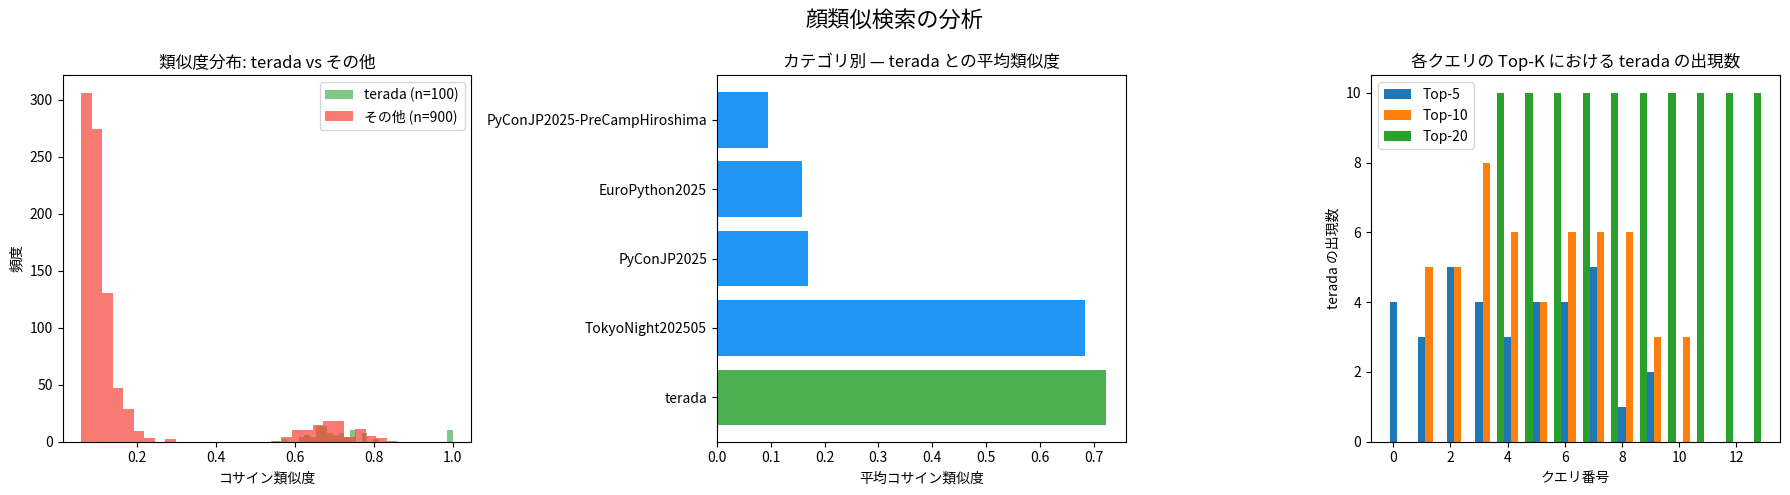

terada 同士の類似度: 平均=0.7232, 最小=0.5665, 最大=1.0000
非terada の類似度: 平均=0.1666, 最小=0.0590, 最大=0.8588


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. terada vs 非terada の類似度分布
terada_sims = df_sim[df_sim["is_terada"]]["similarity"]
other_sims = df_sim[~df_sim["is_terada"]]["similarity"]

axes[0].hist(terada_sims, bins=30, alpha=0.7, label=f"terada (n={len(terada_sims)})", color="#4CAF50")
axes[0].hist(other_sims, bins=30, alpha=0.7, label=f"その他 (n={len(other_sims)})", color="#F44336")
axes[0].set_title("類似度分布: terada vs その他")
axes[0].set_xlabel("コサイン類似度")
axes[0].set_ylabel("頻度")
axes[0].legend()

# 2. カテゴリ別の平均類似度
cat_avg = df_sim.groupby("category")["similarity"].mean().sort_values(ascending=False)
axes[1].barh(cat_avg.index, cat_avg.values, color=["#4CAF50" if c == "terada" else "#2196F3" for c in cat_avg.index])
axes[1].set_title("カテゴリ別 — terada との平均類似度")
axes[1].set_xlabel("平均コサイン類似度")

# 3. 各クエリのTop-K における terada の出現数
for k in [5, 10, 20]:
    query_hits = []
    for _, query_row in terada_query_faces.iterrows():
        q_results = df_sim[df_sim["query"] == query_row["file_name"]].head(k)
        n_terada = q_results["is_terada"].sum()
        query_hits.append(n_terada)
    axes[2].bar(
        np.arange(len(query_hits)) + (k - 5) * 0.25,
        query_hits,
        width=0.25,
        label=f"Top-{k}"
    )

axes[2].set_title("各クエリの Top-K における terada の出現数")
axes[2].set_xlabel("クエリ番号")
axes[2].set_ylabel("terada の出現数")
axes[2].legend()

plt.suptitle("顔類似検索の分析", fontsize=16)
plt.tight_layout()
plt.show()

print(f"terada 同士の類似度: 平均={terada_sims.mean():.4f}, 最小={terada_sims.min():.4f}, 最大={terada_sims.max():.4f}")
print(f"非terada の類似度: 平均={other_sims.mean():.4f}, 最小={other_sims.min():.4f}, 最大={other_sims.max():.4f}")

## 閾値の検討

類似度の閾値を変えて、同一人物検出の精度がどう変わるかを確認する。

In [10]:
thresholds = np.arange(0.1, 0.8, 0.05)
threshold_results = []

for thresh in thresholds:
    above_thresh = df_sim[df_sim["similarity"] >= thresh]
    tp = above_thresh["is_terada"].sum()  # True Positive
    fp = (~above_thresh["is_terada"]).sum()  # False Positive
    below_thresh = df_sim[df_sim["similarity"] < thresh]
    fn = below_thresh["is_terada"].sum()  # False Negative
    tn = (~below_thresh["is_terada"]).sum()  # True Negative

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    threshold_results.append({
        "threshold": thresh,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

df_thresh = pd.DataFrame(threshold_results)

# 最適閾値（F1最大）
best_idx = df_thresh["f1"].idxmax()
best = df_thresh.iloc[best_idx]
print(f"最適閾値 (F1最大): {best['threshold']:.2f}")
print(f"  Precision: {best['precision']:.3f}")
print(f"  Recall: {best['recall']:.3f}")
print(f"  F1: {best['f1']:.3f}")

最適閾値 (F1最大): 0.60
  Precision: 0.516
  Recall: 0.980
  F1: 0.676


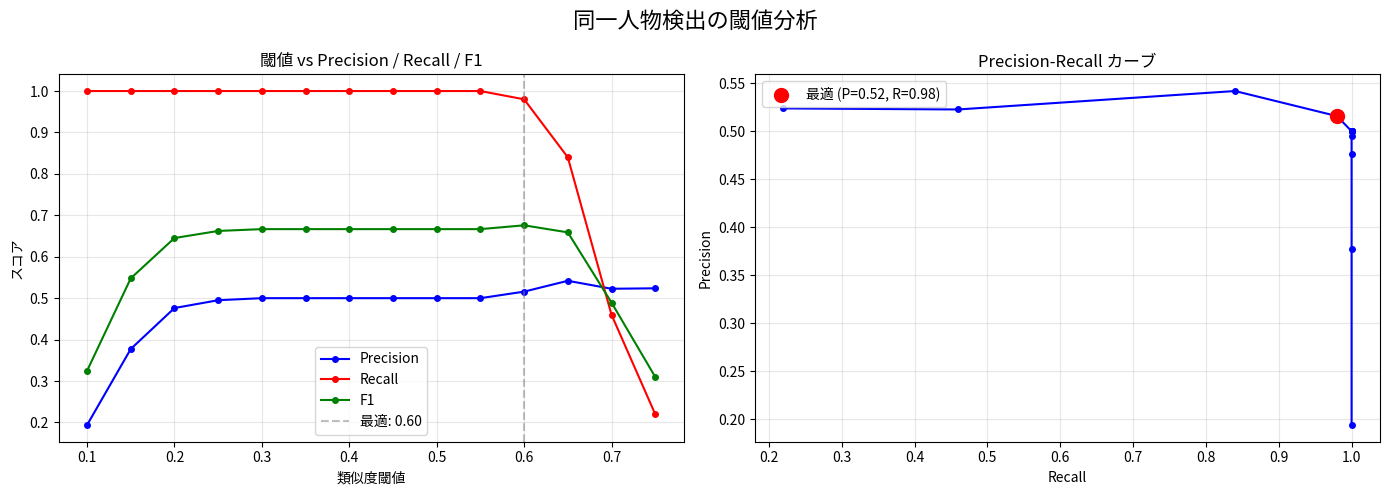

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 vs 閾値
ax1.plot(df_thresh["threshold"], df_thresh["precision"], "b-o", label="Precision", markersize=4)
ax1.plot(df_thresh["threshold"], df_thresh["recall"], "r-o", label="Recall", markersize=4)
ax1.plot(df_thresh["threshold"], df_thresh["f1"], "g-o", label="F1", markersize=4)
ax1.axvline(best["threshold"], color="gray", linestyle="--", alpha=0.5, label=f"最適: {best['threshold']:.2f}")
ax1.set_title("閾値 vs Precision / Recall / F1")
ax1.set_xlabel("類似度閾値")
ax1.set_ylabel("スコア")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precision-Recall カーブ
ax2.plot(df_thresh["recall"], df_thresh["precision"], "b-o", markersize=4)
ax2.set_title("Precision-Recall カーブ")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.grid(True, alpha=0.3)

# 最適点をマーク
ax2.scatter([best["recall"]], [best["precision"]], color="red", s=100, zorder=5,
            label=f"最適 (P={best['precision']:.2f}, R={best['recall']:.2f})")
ax2.legend()

plt.suptitle("同一人物検出の閾値分析", fontsize=16)
plt.tight_layout()
plt.show()

## カンファレンスカテゴリ別のマッチ数

最適閾値を使って、各カンファレンスカテゴリで何件の terada マッチが見つかるか確認する。

In [12]:
# 最適閾値でフィルタリング（terada カテゴリ自身は除外）
optimal_threshold = best["threshold"]

# 各クエリの結果を統合して、ユニークな顔のみカウント
matched_faces = set()
match_details = []

for _, query_row in terada_query_faces.iterrows():
    query_embedding = [float(x) for x in query_row["embedding"]]

    results = conn.execute(f"""
        SELECT 
            f.face_id,
            c.file_name,
            c.file_path,
            c.category,
            f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
            array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        WHERE c.category != 'terada'
        ORDER BY distance
        LIMIT 50
    """, [query_embedding]).fetchdf()

    results["similarity"] = 1.0 - results["distance"]
    matches = results[results["similarity"] >= optimal_threshold]

    for _, m in matches.iterrows():
        if m["face_id"] not in matched_faces:
            matched_faces.add(m["face_id"])
            match_details.append(m)

df_matches = pd.DataFrame(match_details)
print(f"閾値 {optimal_threshold:.2f} での terada マッチ数（terada カテゴリ除く）: {len(df_matches)}")

if len(df_matches) > 0:
    # カテゴリ別マッチ数
    cat_matches = df_matches.groupby("category").size().sort_values(ascending=False)
    print("\nカテゴリ別マッチ数:")
    for cat, count in cat_matches.items():
        print(f"  {cat}: {count}")

閾値 0.60 での terada マッチ数（terada カテゴリ除く）: 10

カテゴリ別マッチ数:
  PyConJP2025: 5
  EuroPython2025: 4
  TokyoNight202505: 1


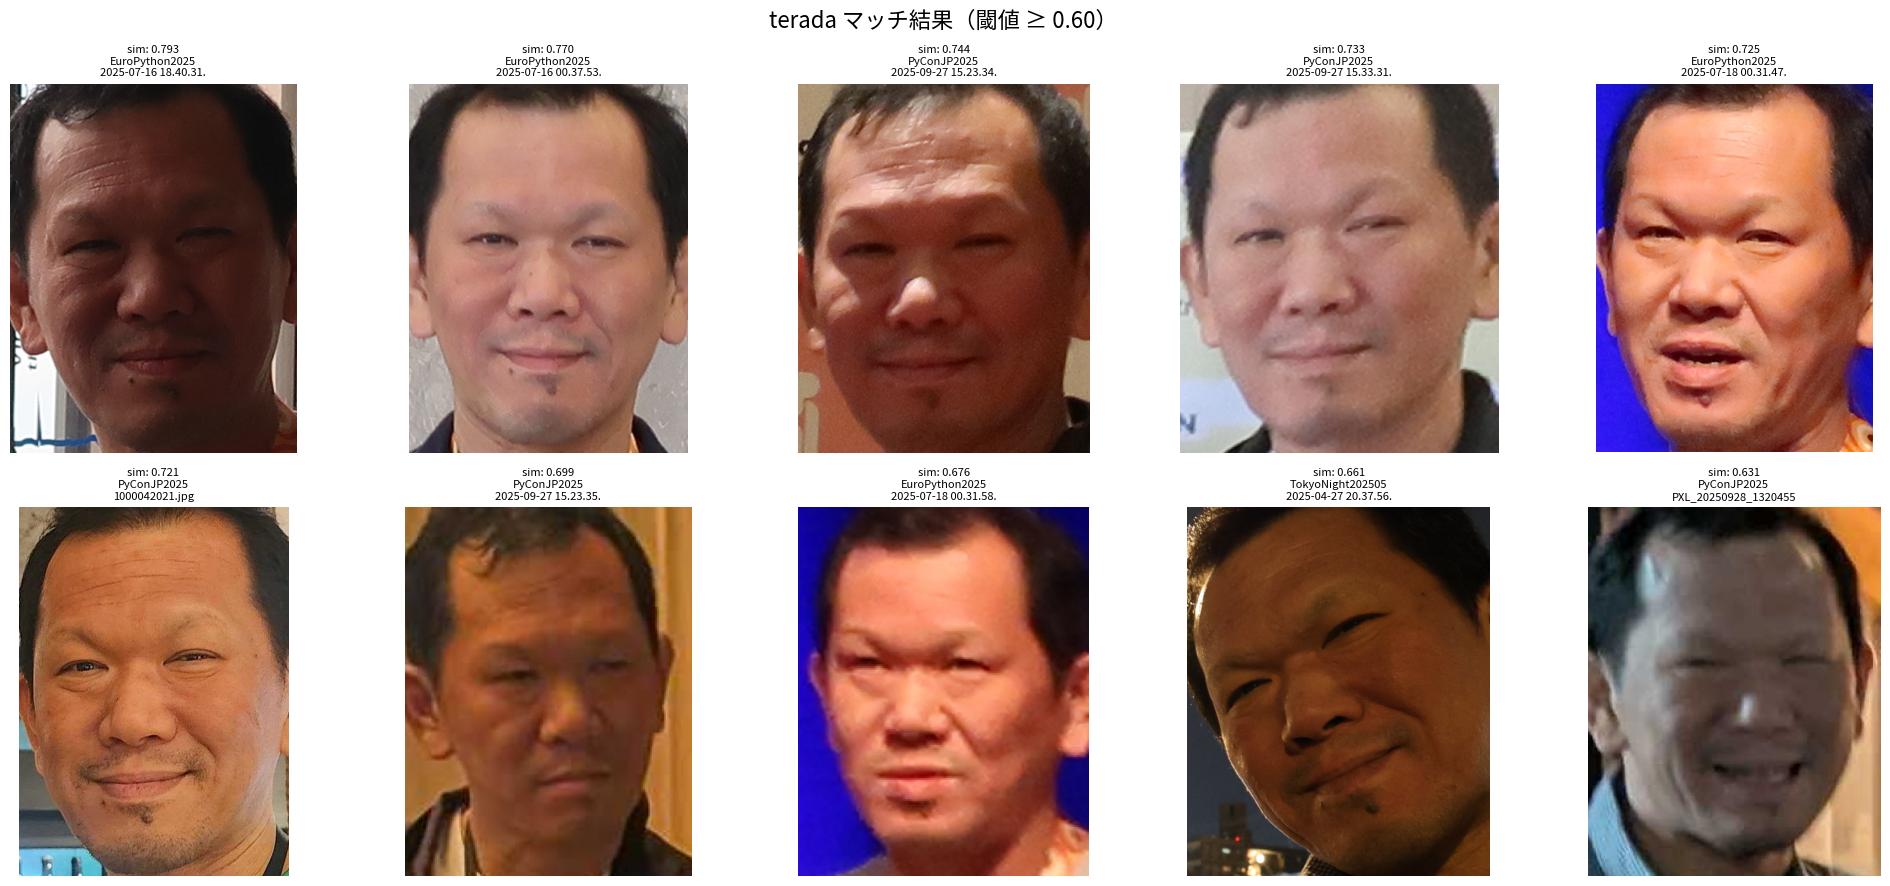

In [13]:
# マッチした顔のグリッド表示
if len(df_matches) > 0:
    n_show = min(len(df_matches), 20)
    df_show = df_matches.sort_values("similarity", ascending=False).head(n_show)

    cols = min(n_show, 5)
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    axes = np.array(axes).flatten()

    for idx, (_, row) in enumerate(df_show.iterrows()):
        try:
            face_crop = crop_face(row["file_path"], row["bbox_x1"], row["bbox_y1"],
                                  row["bbox_x2"], row["bbox_y2"])
            axes[idx].imshow(face_crop)
        except Exception:
            axes[idx].text(0.5, 0.5, "Error", ha="center", va="center", transform=axes[idx].transAxes)

        axes[idx].set_title(
            f"sim: {row['similarity']:.3f}\n{row['category']}\n{row['file_name'][:20]}",
            fontsize=8
        )
        axes[idx].axis("off")

    for i in range(n_show, len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"terada マッチ結果（閾値 ≥ {optimal_threshold:.2f}）", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("マッチなし — 閾値を下げてみてください")

## マッチ結果を元画像上で確認

マッチした顔が元画像のどこに位置するかを確認する。

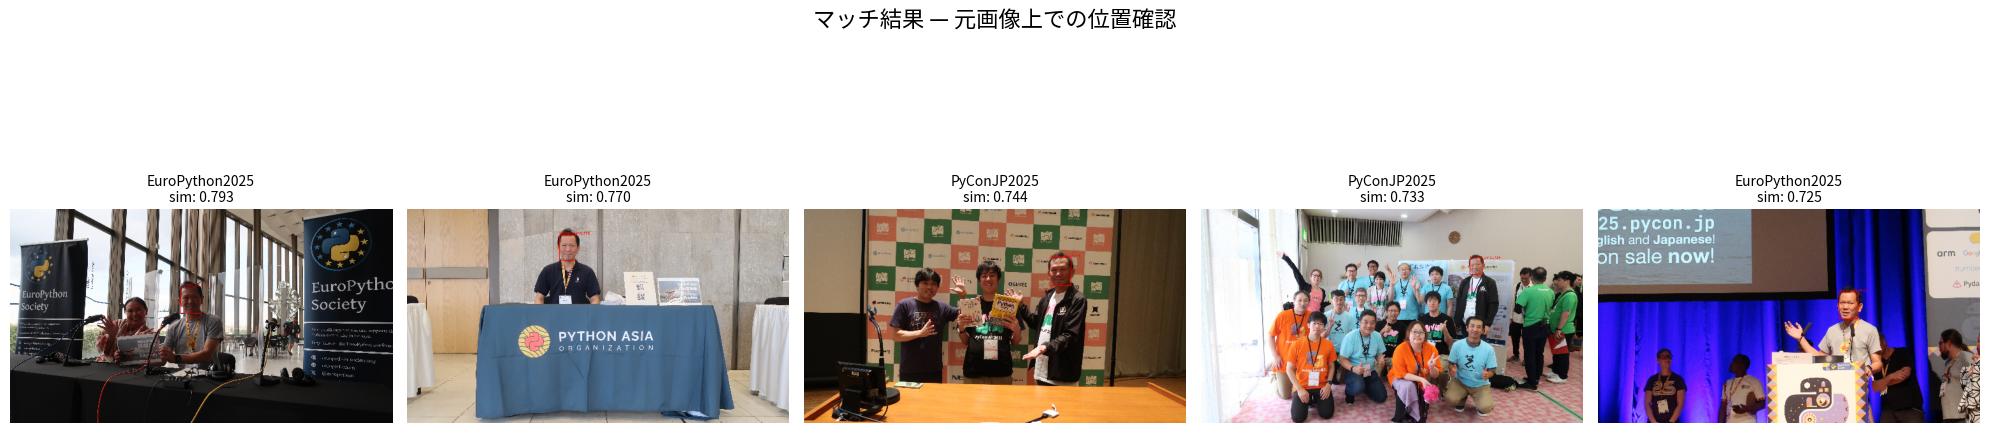

In [14]:
if len(df_matches) > 0:
    # 上位5件の元画像にバウンディングボックスを表示
    top_matches = df_matches.sort_values("similarity", ascending=False).head(5)

    fig, axes = plt.subplots(1, min(5, len(top_matches)), figsize=(20, 6))
    if len(top_matches) == 1:
        axes = [axes]

    for idx, (_, row) in enumerate(top_matches.iterrows()):
        img = cv2.imread(row["file_path"])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # マッチした顔のBBox を赤で描画
        bbox = [int(row["bbox_x1"]), int(row["bbox_y1"]), int(row["bbox_x2"]), int(row["bbox_y2"])]
        cv2.rectangle(img_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (255, 0, 0), 5)
        cv2.putText(img_rgb, f"terada? sim:{row['similarity']:.3f}",
                    (bbox[0], bbox[1] - 15), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)

        # リサイズ
        h, w = img_rgb.shape[:2]
        max_w = 600
        if w > max_w:
            scale = max_w / w
            img_rgb = cv2.resize(img_rgb, (max_w, int(h * scale)))

        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"{row['category']}\nsim: {row['similarity']:.3f}", fontsize=10)
        axes[idx].axis("off")

    plt.suptitle("マッチ結果 — 元画像上での位置確認", fontsize=16)
    plt.tight_layout()
    plt.show()

## まとめ

### 確認事項
- terada のポートレートをクエリとして、カンファレンス写真群から同一人物を検索できた
- 1画像に複数顔がある場合でも、個別の顔ごとにマッチングが行われる
- 類似度スコアの分布から、同一人物 vs 別人物の閾値を特定
- 顔レベルの検索は、画像レベルの CLIP 検索とは異なり、「誰が写っているか」に特化

### 次のステップ
- **Notebook 54**: 教師なしクラスタリングで全顔の自動グループ化を試みる

In [15]:
conn.close()
print("完了")

完了
